# 💳 Credit Card Default Prediction — PyTorch
### Dataset: Default of Credit Card Clients (UCI / Taiwan 2005)
---
**Tujuan:** Membangun model Deep Neural Network (DNN) dengan PyTorch untuk memprediksi apakah nasabah kartu kredit akan **gagal bayar (default)** pada bulan berikutnya.

| Info | Detail |
|---|---|
| Jumlah Sampel | 30,000 nasabah |
| Jumlah Fitur | 23 fitur asli + fitur rekayasa |
| Target | `DEFAULT` — 0 = tidak default, 1 = default |
| Imbalance | ~78% tidak default vs ~22% default |
| Framework | PyTorch + scikit-learn + imbalanced-learn |


## ⚙️ 0. Install Dependencies

In [1]:
# Jalankan cell ini sekali jika belum install
# !pip install torch scikit-learn imbalanced-learn matplotlib seaborn pandas numpy

print("✅ Library siap digunakan")


✅ Library siap digunakan


## 📦 1. Import Library & Load Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score
)
from imblearn.over_sampling import SMOTE
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# ── Load Dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv('default of credit card clients.csv')
df.rename(columns={'default payment next month': 'DEFAULT'}, inplace=True)
df.drop(columns=['ID'], inplace=True)

print("=" * 55)
print(f"  Shape dataset       : {df.shape}")
print(f"  Jumlah fitur        : {df.shape[1] - 1}")
print(f"  Jumlah sampel       : {df.shape[0]:,}")
print(f"  Missing values      : {df.isnull().sum().sum()}")
print("=" * 55)
vc = df['DEFAULT'].value_counts()
print(f"  Tidak Default (0)   : {vc[0]:,}  ({vc[0]/len(df)*100:.1f}%)")
print(f"  Default       (1)   : {vc[1]:,}  ({vc[1]/len(df)*100:.1f}%)")
print("=" * 55)
df.head()


  Shape dataset       : (30000, 24)
  Jumlah fitur        : 23
  Jumlah sampel       : 30,000
  Missing values      : 0
  Tidak Default (0)   : 23,364  (77.9%)
  Default       (1)   : 6,636  (22.1%)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
!pip install imbalanced-learn

## 📊 2. Exploratory Data Analysis (EDA)

### 2.1 Distribusi Target & Demografi

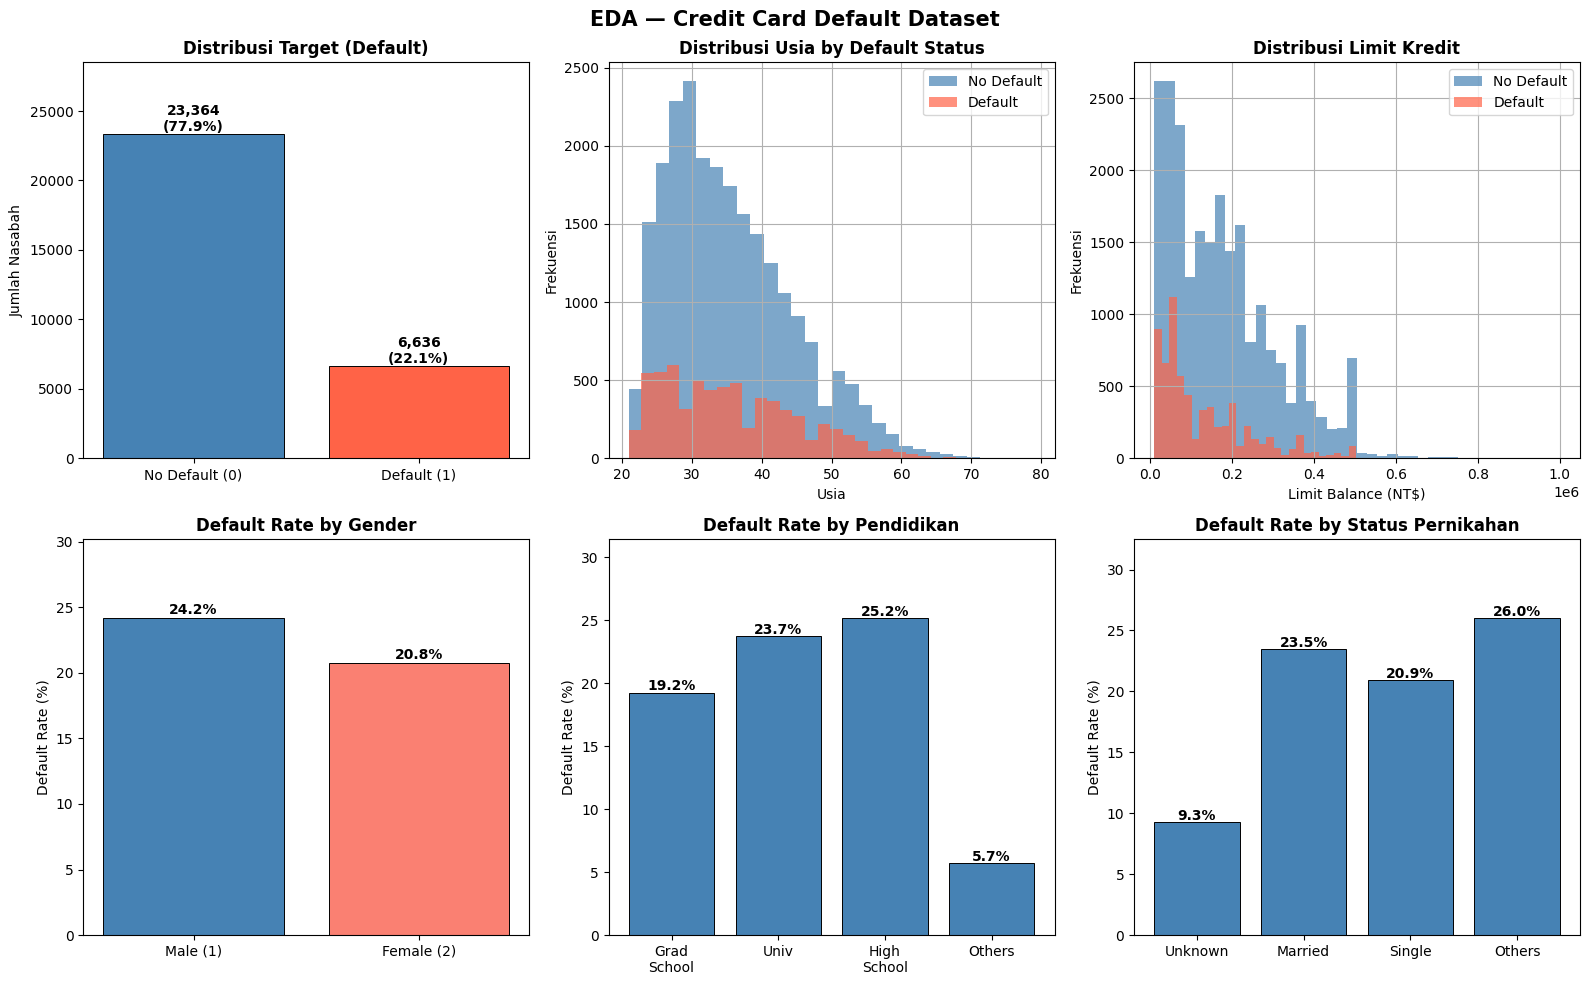

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA — Credit Card Default Dataset', fontsize=15, fontweight='bold')

# 1. Target Distribution
ax = axes[0, 0]
counts = df['DEFAULT'].value_counts()
bars = ax.bar(['No Default (0)', 'Default (1)'], counts.values,
              color=['steelblue', 'tomato'], edgecolor='black', linewidth=0.7)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 200,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Distribusi Target (Default)', fontweight='bold')
ax.set_ylabel('Jumlah Nasabah')
ax.set_ylim(0, counts.max() * 1.22)

# 2. Age Distribution
ax = axes[0, 1]
df[df['DEFAULT']==0]['AGE'].hist(ax=ax, bins=30, alpha=0.7, label='No Default', color='steelblue')
df[df['DEFAULT']==1]['AGE'].hist(ax=ax, bins=30, alpha=0.7, label='Default',    color='tomato')
ax.set_title('Distribusi Usia by Default Status', fontweight='bold')
ax.set_xlabel('Usia'); ax.set_ylabel('Frekuensi')
ax.legend()

# 3. Limit Balance Distribution
ax = axes[0, 2]
df[df['DEFAULT']==0]['LIMIT_BAL'].hist(ax=ax, bins=40, alpha=0.7, label='No Default', color='steelblue')
df[df['DEFAULT']==1]['LIMIT_BAL'].hist(ax=ax, bins=40, alpha=0.7, label='Default',    color='tomato')
ax.set_title('Distribusi Limit Kredit', fontweight='bold')
ax.set_xlabel('Limit Balance (NT$)'); ax.set_ylabel('Frekuensi')
ax.legend()

# 4. Default Rate by Gender
ax = axes[1, 0]
sex_rate = df.groupby('SEX')['DEFAULT'].mean() * 100
ax.bar(['Male (1)', 'Female (2)'], sex_rate.values, color=['steelblue','salmon'], edgecolor='black', linewidth=0.7)
for i, v in enumerate(sex_rate.values):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_title('Default Rate by Gender', fontweight='bold')
ax.set_ylabel('Default Rate (%)'); ax.set_ylim(0, sex_rate.max() * 1.25)

# 5. Default Rate by Education
ax = axes[1, 1]
edu_map = {1: 'Grad\nSchool', 2: 'Univ', 3: 'High\nSchool', 4: 'Others'}
edu_df = df[df['EDUCATION'].isin([1,2,3,4])]
edu_rate = edu_df.groupby('EDUCATION')['DEFAULT'].mean() * 100
ax.bar([edu_map[i] for i in edu_rate.index], edu_rate.values, color='steelblue', edgecolor='black', linewidth=0.7)
for i, v in enumerate(edu_rate.values):
    ax.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_title('Default Rate by Pendidikan', fontweight='bold')
ax.set_ylabel('Default Rate (%)'); ax.set_ylim(0, edu_rate.max() * 1.25)

# 6. Default Rate by Marriage
ax = axes[1, 2]
mar_map = {0: 'Unknown', 1: 'Married', 2: 'Single', 3: 'Others'}
mar_rate = df.groupby('MARRIAGE')['DEFAULT'].mean() * 100
ax.bar([mar_map.get(i, str(i)) for i in mar_rate.index], mar_rate.values,
       color='steelblue', edgecolor='black', linewidth=0.7)
for i, v in enumerate(mar_rate.values):
    ax.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_title('Default Rate by Status Pernikahan', fontweight='bold')
ax.set_ylabel('Default Rate (%)'); ax.set_ylim(0, mar_rate.max() * 1.25)

plt.tight_layout()
plt.show()


### 2.2 Analisis Riwayat Pembayaran & Tagihan

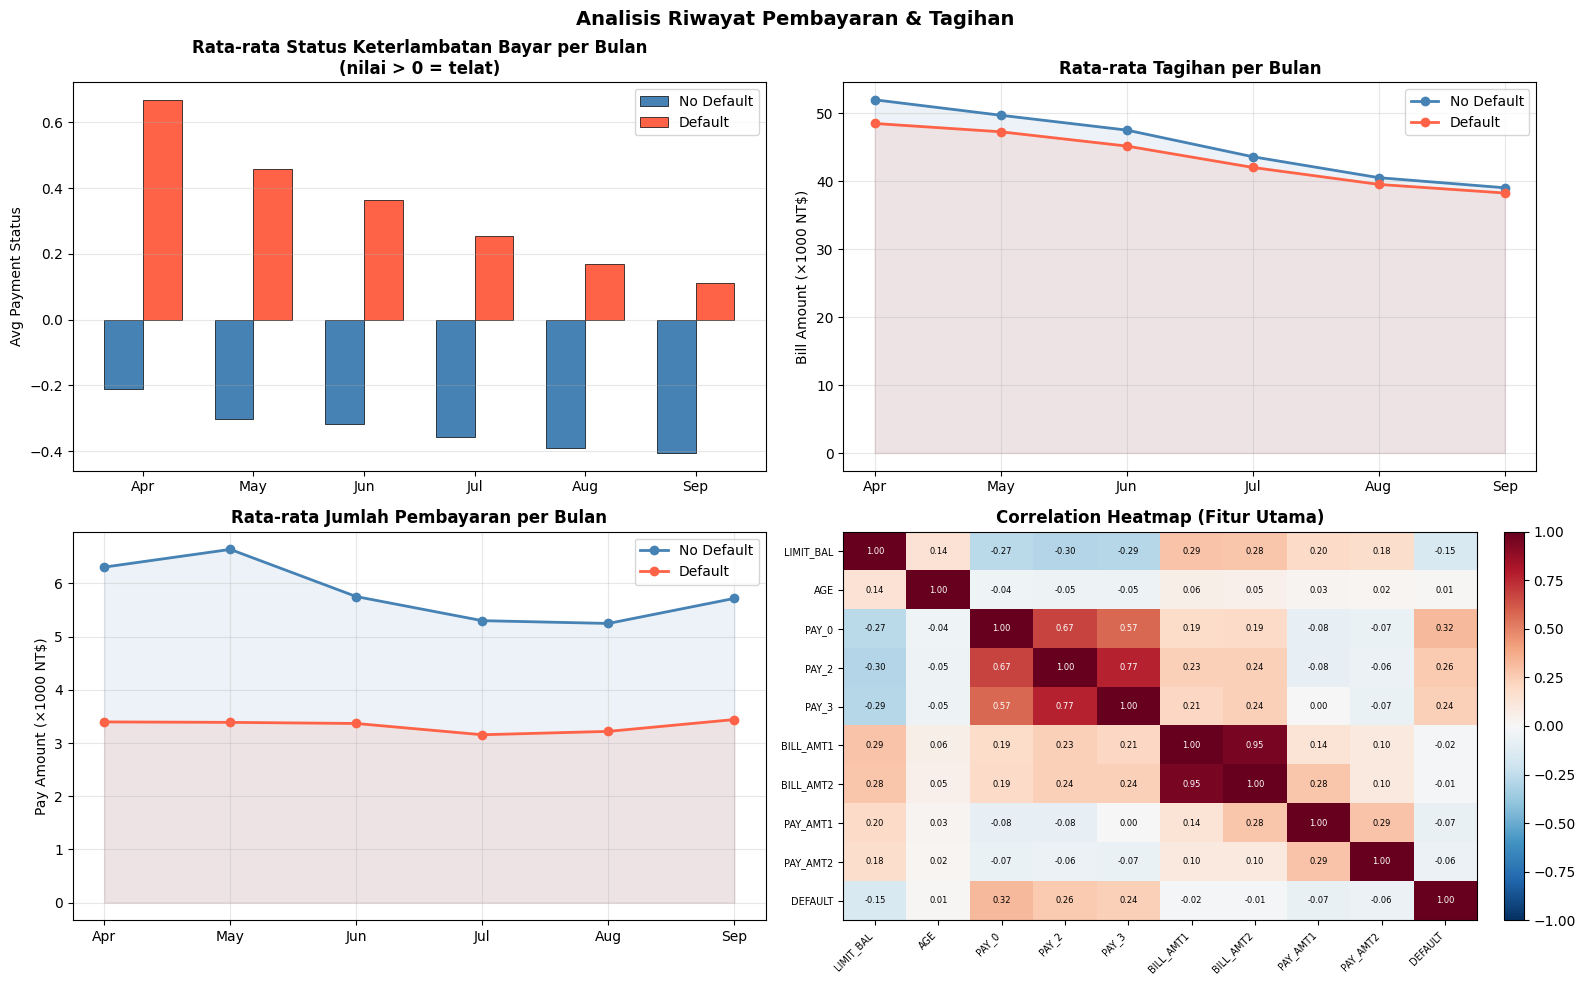

In [5]:
pay_cols     = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
bill_cols    = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
pay_amt_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']
months       = ['Apr','May','Jun','Jul','Aug','Sep']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Analisis Riwayat Pembayaran & Tagihan', fontsize=14, fontweight='bold')

# 1. Avg payment delay status
ax = axes[0, 0]
avg_no  = df[df['DEFAULT']==0][pay_cols].mean().values
avg_yes = df[df['DEFAULT']==1][pay_cols].mean().values
x = np.arange(len(months)); w = 0.35
ax.bar(x - w/2, avg_no,  w, label='No Default', color='steelblue', edgecolor='black', linewidth=0.5)
ax.bar(x + w/2, avg_yes, w, label='Default',    color='tomato',    edgecolor='black', linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(months)
ax.set_title('Rata-rata Status Keterlambatan Bayar per Bulan\n(nilai > 0 = telat)', fontweight='bold')
ax.set_ylabel('Avg Payment Status'); ax.legend(); ax.grid(axis='y', alpha=0.3)

# 2. Avg Bill Amount
ax = axes[0, 1]
b_no  = df[df['DEFAULT']==0][bill_cols].mean().values / 1000
b_yes = df[df['DEFAULT']==1][bill_cols].mean().values / 1000
ax.plot(months, b_no,  'o-', label='No Default', color='steelblue', lw=2)
ax.plot(months, b_yes, 'o-', label='Default',    color='tomato',    lw=2)
ax.fill_between(months, b_no,  alpha=0.1, color='steelblue')
ax.fill_between(months, b_yes, alpha=0.1, color='tomato')
ax.set_title('Rata-rata Tagihan per Bulan', fontweight='bold')
ax.set_ylabel('Bill Amount (×1000 NT$)'); ax.legend(); ax.grid(alpha=0.3)

# 3. Avg Pay Amount
ax = axes[1, 0]
p_no  = df[df['DEFAULT']==0][pay_amt_cols].mean().values / 1000
p_yes = df[df['DEFAULT']==1][pay_amt_cols].mean().values / 1000
ax.plot(months, p_no,  'o-', label='No Default', color='steelblue', lw=2)
ax.plot(months, p_yes, 'o-', label='Default',    color='tomato',    lw=2)
ax.fill_between(months, p_no,  alpha=0.1, color='steelblue')
ax.fill_between(months, p_yes, alpha=0.1, color='tomato')
ax.set_title('Rata-rata Jumlah Pembayaran per Bulan', fontweight='bold')
ax.set_ylabel('Pay Amount (×1000 NT$)'); ax.legend(); ax.grid(alpha=0.3)

# 4. Correlation Heatmap
ax = axes[1, 1]
key_cols = ['LIMIT_BAL','AGE','PAY_0','PAY_2','PAY_3','BILL_AMT1','BILL_AMT2','PAY_AMT1','PAY_AMT2','DEFAULT']
corr = df[key_cols].corr()
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(key_cols))); ax.set_yticks(range(len(key_cols)))
ax.set_xticklabels(key_cols, rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(key_cols, fontsize=7)
for i in range(len(key_cols)):
    for j in range(len(key_cols)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center',
                fontsize=6, color='white' if abs(corr.values[i,j]) > 0.5 else 'black')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Correlation Heatmap (Fitur Utama)', fontweight='bold')

plt.tight_layout()
plt.show()


### 2.3 Statistik Deskriptif

In [6]:
print("── Statistik Deskriptif Dataset ──")
desc = df.describe().T
desc['cv'] = desc['std'] / desc['mean']  # Coefficient of Variation
display(desc[['count','mean','std','min','25%','50%','75%','max','cv']].round(2))


── Statistik Deskriptif Dataset ──


,count,mean,std,min,25%,50%,75%,max,cv
LIMIT_BAL,30000.0,167484.32,129747.66,10000.0,50000.00,140000.0,240000.00,1000000.0,0.77
SEX,30000.0,1.60,0.49,1.0,1.00,2.0,2.00,2.0,0.30
EDUCATION,30000.0,1.85,0.79,0.0,1.00,2.0,2.00,6.0,0.43
MARRIAGE,30000.0,1.55,0.52,0.0,1.00,2.0,2.00,3.0,0.34
AGE,30000.0,35.49,9.22,21.0,28.00,34.0,41.00,79.0,0.26
PAY_0,30000.0,-0.02,1.12,-2.0,-1.00,0.0,0.00,8.0,-67.29
PAY_2,30000.0,-0.13,1.20,-2.0,-1.00,0.0,0.00,8.0,-8.95
PAY_3,30000.0,-0.17,1.20,-2.0,-1.00,0.0,0.00,8.0,-7.20
PAY_4,30000.0,-0.22,1.17,-2.0,-1.00,0.0,0.00,8.0,-5.30
PAY_5,30000.0,-0.27,1.13,-2.0,-1.00,0.0,0.00,8.0,-4.26


## 🔧 3. Feature Engineering

In [7]:
df_fe = df.copy()

# 1. Utilization ratio per bulan (tagihan / limit)
for i in range(1, 7):
    df_fe[f'UTIL_{i}'] = df_fe[f'BILL_AMT{i}'] / (df_fe['LIMIT_BAL'] + 1)

# 2. Payment ratio per bulan (bayar / tagihan)
for i in range(1, 7):
    df_fe[f'PAY_RATIO_{i}'] = df_fe[f'PAY_AMT{i}'] / (df_fe[f'BILL_AMT{i}'].abs() + 1)

# 3. Fitur keterlambatan agregat
pay_status_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
df_fe['TOTAL_DELAY_COUNT'] = (df_fe[pay_status_cols] > 0).sum(axis=1)
df_fe['MAX_DELAY']         =  df_fe[pay_status_cols].max(axis=1)
df_fe['AVG_DELAY']         =  df_fe[pay_status_cols].mean(axis=1)

# 4. Tren tagihan & pembayaran (bulan terbaru vs 6 bulan lalu)
df_fe['BILL_TREND']    = df_fe['BILL_AMT1'] - df_fe['BILL_AMT6']
df_fe['PAY_AMT_TREND'] = df_fe['PAY_AMT1']  - df_fe['PAY_AMT6']

# 5. Rata-rata tagihan & pembayaran
bill_cols    = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
pay_amt_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']
df_fe['AVG_BILL']    = df_fe[bill_cols].mean(axis=1)
df_fe['AVG_PAY_AMT'] = df_fe[pay_amt_cols].mean(axis=1)

print(f"Fitur asli          : {df.shape[1] - 1}")
print(f"Fitur setelah FE    : {df_fe.shape[1] - 1}")
print(f"Fitur baru ditambah : {df_fe.shape[1] - df.shape[1]}")
print("\nFitur baru:", [c for c in df_fe.columns if c not in df.columns])


Fitur asli          : 23
Fitur setelah FE    : 42
Fitur baru ditambah : 19

Fitur baru: ['UTIL_1', 'UTIL_2', 'UTIL_3', 'UTIL_4', 'UTIL_5', 'UTIL_6', 'PAY_RATIO_1', 'PAY_RATIO_2', 'PAY_RATIO_3', 'PAY_RATIO_4', 'PAY_RATIO_5', 'PAY_RATIO_6', 'TOTAL_DELAY_COUNT', 'MAX_DELAY', 'AVG_DELAY', 'BILL_TREND', 'PAY_AMT_TREND', 'AVG_BILL', 'AVG_PAY_AMT']


## 🔀 4. Preprocessing & Split Data

In [8]:
X = df_fe.drop(columns=['DEFAULT'])
y = df_fe['DEFAULT']

# Train / Val / Test  =  70% / 15% / 15%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

# Standardisasi
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# SMOTE — oversample kelas minoritas hanya pada training set
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_sc, y_train)

print("Ukuran Split:")
print(f"  Train (sebelum SMOTE) : {X_train_sc.shape}   | Default rate: {y_train.mean()*100:.1f}%")
print(f"  Train (sesudah SMOTE) : {X_train_res.shape} | Default rate: {y_train_res.mean()*100:.1f}%")
print(f"  Validation            : {X_val_sc.shape}   | Default rate: {y_val.mean()*100:.1f}%")
print(f"  Test                  : {X_test_sc.shape}   | Default rate: {y_test.mean()*100:.1f}%")


Ukuran Split:
  Train (sebelum SMOTE) : (21000, 42)   | Default rate: 22.1%
  Train (sesudah SMOTE) : (32710, 42) | Default rate: 50.0%
  Validation            : (4500, 42)   | Default rate: 22.1%
  Test                  : (4500, 42)   | Default rate: 22.1%


## 🧠 5. Arsitektur Model PyTorch

In [9]:
# ── PyTorch Dataset ───────────────────────────────────────────────────────────
def make_tensor(X, y_arr):
    y_vals = y_arr.values if hasattr(y_arr, 'values') else np.array(y_arr)
    return TensorDataset(
        torch.FloatTensor(X),
        torch.FloatTensor(y_vals)
    )

train_ds = make_tensor(X_train_res, y_train_res)
val_ds   = make_tensor(X_val_sc,   y_val)
test_ds  = make_tensor(X_test_sc,  y_test)

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True,  drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=512, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False)

# ── Model Definition ──────────────────────────────────────────────────────────
class CreditDefaultNet(nn.Module):
    # \"\"\"
    # Deep Neural Network untuk klasifikasi default kartu kredit.
    # Arsitektur: 4 hidden layers dengan BatchNorm + Dropout.
    # \"\"\"
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            # Block 1
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.35),
            # Block 2
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.30),
            # Block 3
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.25),
            # Block 4
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.20),
            # Output
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(1)

device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_dim  = X_train_res.shape[1]
model      = CreditDefaultNet(input_dim).to(device)

print(f"Device            : {device}")
print(f"Input dimension   : {input_dim}")
print(f"Total parameters  : {sum(p.numel() for p in model.parameters()):,}")
print("\nArsitektur Model:")
print(model)


Device            : cuda
Input dimension   : 42
Total parameters  : 55,233

Arsitektur Model:
CreditDefaultNet(
  (net): Sequential(
    (0): Linear(in_features=42, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.35, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.25, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.2, inplace=False)
    (16): Linear(in_features=32, out_

## 🏋️ 6. Training Model

In [11]:
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=7, factor=0.5)
criterion = nn.BCELoss()

EPOCHS = 80
best_val_auc   = 0.0
best_model_wts = None
history        = {'train_loss': [], 'val_loss': [], 'val_auc': []}

print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>9} | {'Val AUC':>8}")
print("-" * 45)

for epoch in range(1, EPOCHS + 1):
    # ── Training ──
    model.train()
    tr_losses = []
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        tr_losses.append(loss.item())

    # ── Validation ──
    model.eval()
    vl_losses, vl_preds, vl_true = [], [], []
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            out = model(X_b)
            vl_losses.append(criterion(out, y_b).item())
            vl_preds.extend(out.cpu().numpy())
            vl_true.extend(y_b.cpu().numpy())

    tr_loss = np.mean(tr_losses)
    vl_loss = np.mean(vl_losses)
    vl_auc  = roc_auc_score(vl_true, vl_preds)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['val_auc'].append(vl_auc)

    scheduler.step(vl_loss)

    if vl_auc > best_val_auc:
        best_val_auc   = vl_auc
        best_model_wts = {k: v.clone() for k, v in model.state_dict().items()}

    if epoch % 10 == 0:
        print(f"{epoch:>6} | {tr_loss:>10.4f} | {vl_loss:>9.4f} | {vl_auc:>8.4f}")

print("-" * 45)
print(f"\n✅ Best Validation AUC : {best_val_auc:.4f}")

# # Muat bobot terbaik
# model.load_state_dict(best_model_wts)
# torch.save(model.state_dict(), 'best_credit_model.pth')
# print("💾 Model disimpan ke : best_credit_model.pth")


 Epoch | Train Loss |  Val Loss |  Val AUC
---------------------------------------------
    10 |     0.5399 |    0.5543 |   0.7714
    20 |     0.5253 |    0.5455 |   0.7636
    30 |     0.5113 |    0.5380 |   0.7577
    40 |     0.4949 |    0.5534 |   0.7522
    50 |     0.4819 |    0.5553 |   0.7495
    60 |     0.4779 |    0.5640 |   0.7486
    70 |     0.4732 |    0.5597 |   0.7463
    80 |     0.4745 |    0.5496 |   0.7449
---------------------------------------------

✅ Best Validation AUC : 0.7731


## 📈 7. Visualisasi Proses Training

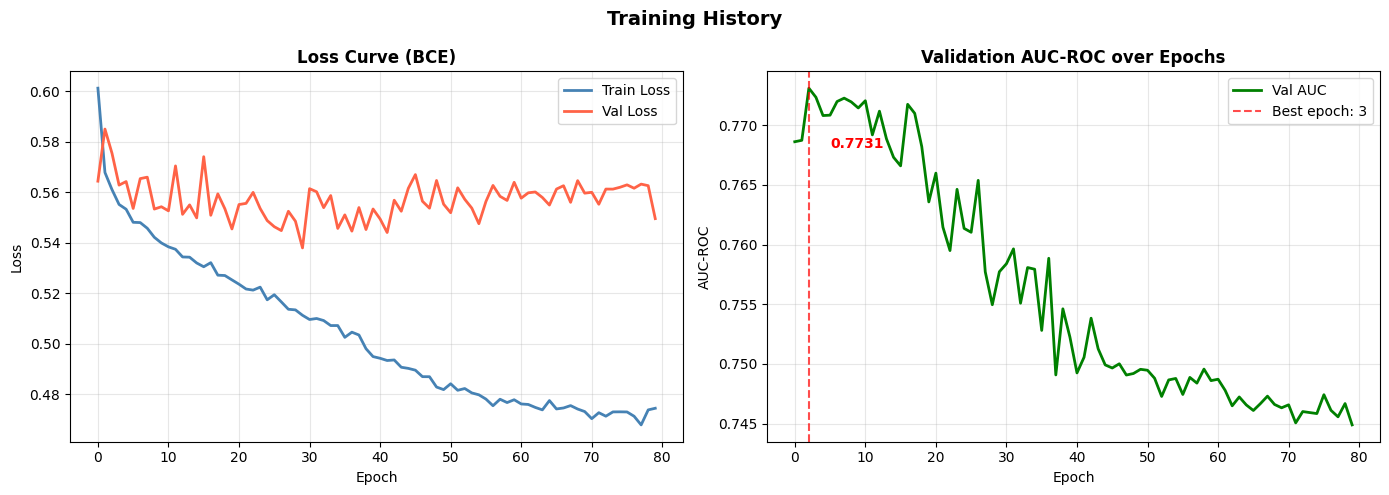

Best epoch        : 3
Best Val AUC      : 0.7731
Final Train Loss  : 0.4745
Final Val Loss    : 0.5496


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

# Loss Curve
ax = axes[0]
ax.plot(history['train_loss'], label='Train Loss', color='steelblue', lw=2)
ax.plot(history['val_loss'],   label='Val Loss',   color='tomato',    lw=2)
ax.set_title('Loss Curve (BCE)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

# AUC Curve
ax = axes[1]
ax.plot(history['val_auc'], label='Val AUC', color='green', lw=2)
best_epoch = int(np.argmax(history['val_auc']))
ax.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.7,
           label=f'Best epoch: {best_epoch+1}')
ax.annotate(f'{best_val_auc:.4f}',
            xy=(best_epoch, best_val_auc),
            xytext=(best_epoch + 3, best_val_auc - 0.005),
            fontsize=10, color='red', fontweight='bold')
ax.set_title('Validation AUC-ROC over Epochs', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('AUC-ROC')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best epoch        : {best_epoch + 1}")
print(f"Best Val AUC      : {best_val_auc:.4f}")
print(f"Final Train Loss  : {history['train_loss'][-1]:.4f}")
print(f"Final Val Loss    : {history['val_loss'][-1]:.4f}")


## 🎯 8. Evaluasi Model pada Test Set

In [13]:
model.eval()
test_probs, test_true = [], []

with torch.no_grad():
    for X_b, y_b in test_loader:
        out = model(X_b.to(device))
        test_probs.extend(out.cpu().numpy())
        test_true.extend(y_b.numpy())

test_probs = np.array(test_probs)
test_true  = np.array(test_true)

# ── Cari threshold optimal berdasarkan F1 ──
thresholds = np.arange(0.20, 0.80, 0.01)
f1_scores  = [f1_score(test_true, (test_probs >= t).astype(int)) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]
test_preds  = (test_probs >= best_thresh).astype(int)

print("=" * 60)
print(f"  Optimal Threshold (F1-based) : {best_thresh:.2f}")
print(f"  Test AUC-ROC                 : {roc_auc_score(test_true, test_probs):.4f}")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(test_true, test_preds, target_names=['No Default', 'Default']))


  Optimal Threshold (F1-based) : 0.58
  Test AUC-ROC                 : 0.7523

Classification Report:
              precision    recall  f1-score   support

  No Default       0.86      0.85      0.86      3504
     Default       0.50      0.53      0.51       996

    accuracy                           0.78      4500
   macro avg       0.68      0.69      0.68      4500
weighted avg       0.78      0.78      0.78      4500



### 8.1 Visualisasi Evaluasi

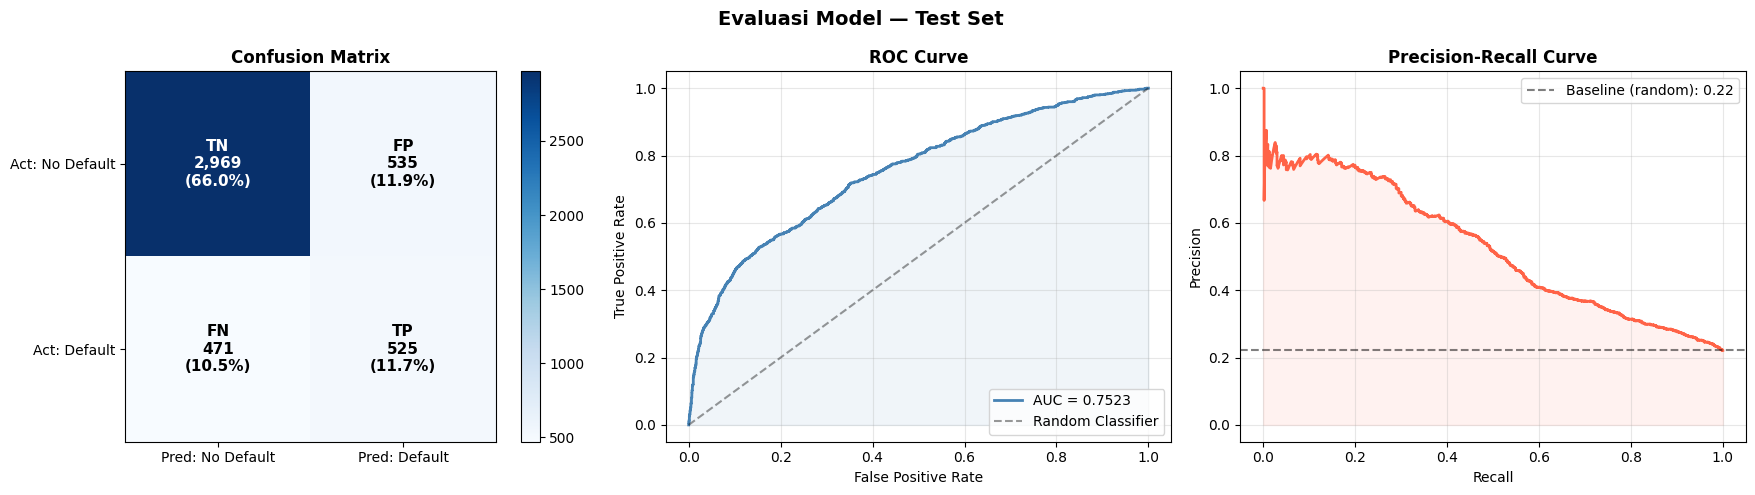

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Evaluasi Model — Test Set', fontsize=14, fontweight='bold')

# 1. Confusion Matrix
ax = axes[0]
cm = confusion_matrix(test_true, test_preds)
total = cm.sum()
im = ax.imshow(cm, cmap='Blues')
labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{labels[i][j]}\n{cm[i,j]:,}\n({cm[i,j]/total*100:.1f}%)',
                ha='center', va='center', fontsize=11, fontweight='bold',
                color='white' if cm[i,j] > cm.max() / 2 else 'black')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Pred: No Default', 'Pred: Default'])
ax.set_yticklabels(['Act: No Default', 'Act: Default'])
ax.set_title('Confusion Matrix', fontweight='bold')
plt.colorbar(im, ax=ax)

# 2. ROC Curve
ax = axes[1]
fpr, tpr, _ = roc_curve(test_true, test_probs)
auc_val = roc_auc_score(test_true, test_probs)
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc_val:.4f}')
ax.plot([0,1],[0,1], 'k--', alpha=0.4, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.08, color='steelblue')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve', fontweight='bold')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)

# 3. Precision-Recall Curve
ax = axes[2]
prec, rec, _ = precision_recall_curve(test_true, test_probs)
baseline = test_true.mean()
ax.plot(rec, prec, color='tomato', lw=2)
ax.fill_between(rec, prec, alpha=0.08, color='tomato')
ax.axhline(y=baseline, color='k', linestyle='--', alpha=0.5,
           label=f'Baseline (random): {baseline:.2f}')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 8.2 Analisis Threshold

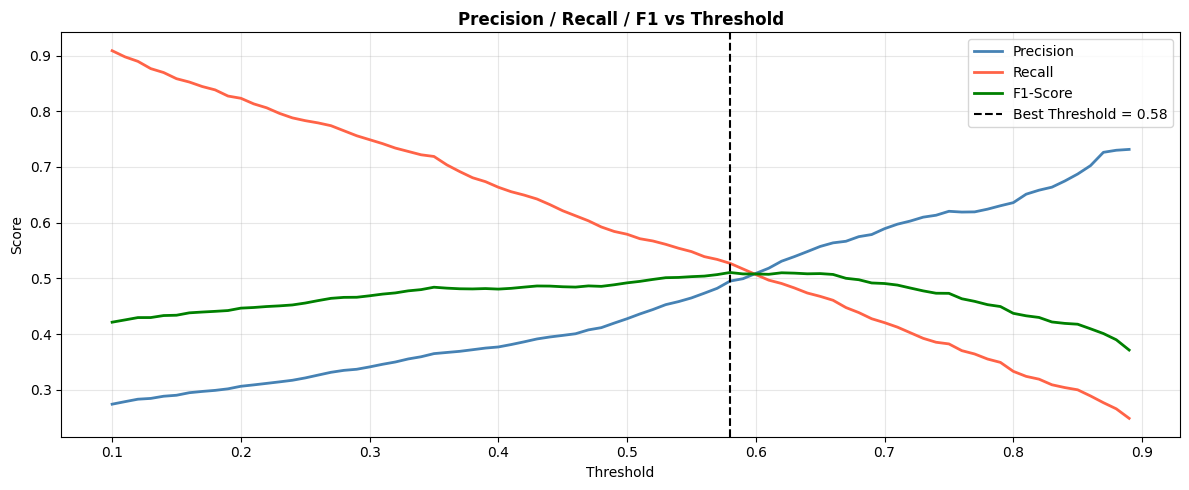

Pada threshold optimal (0.58):
  Precision : 0.4953
  Recall    : 0.5271
  F1-Score  : 0.5107


In [15]:
thresholds_plot = np.arange(0.10, 0.90, 0.01)
precisions, recalls, f1s = [], [], []

for t in thresholds_plot:
    preds = (test_probs >= t).astype(int)
    from sklearn.metrics import precision_score, recall_score
    precisions.append(precision_score(test_true, preds, zero_division=0))
    recalls.append(recall_score(test_true, preds, zero_division=0))
    f1s.append(f1_score(test_true, preds, zero_division=0))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresholds_plot, precisions, label='Precision', color='steelblue', lw=2)
ax.plot(thresholds_plot, recalls,    label='Recall',    color='tomato',    lw=2)
ax.plot(thresholds_plot, f1s,        label='F1-Score',  color='green',     lw=2)
ax.axvline(x=best_thresh, color='black', linestyle='--', lw=1.5,
           label=f'Best Threshold = {best_thresh:.2f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Threshold', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Pada threshold optimal ({best_thresh:.2f}):")
best_idx = np.argmin(np.abs(thresholds_plot - best_thresh))
print(f"  Precision : {precisions[best_idx]:.4f}")
print(f"  Recall    : {recalls[best_idx]:.4f}")
print(f"  F1-Score  : {f1s[best_idx]:.4f}")


## 🔍 9. Feature Importance (Permutation-based)

Menghitung permutation importance... (mungkin butuh beberapa menit)


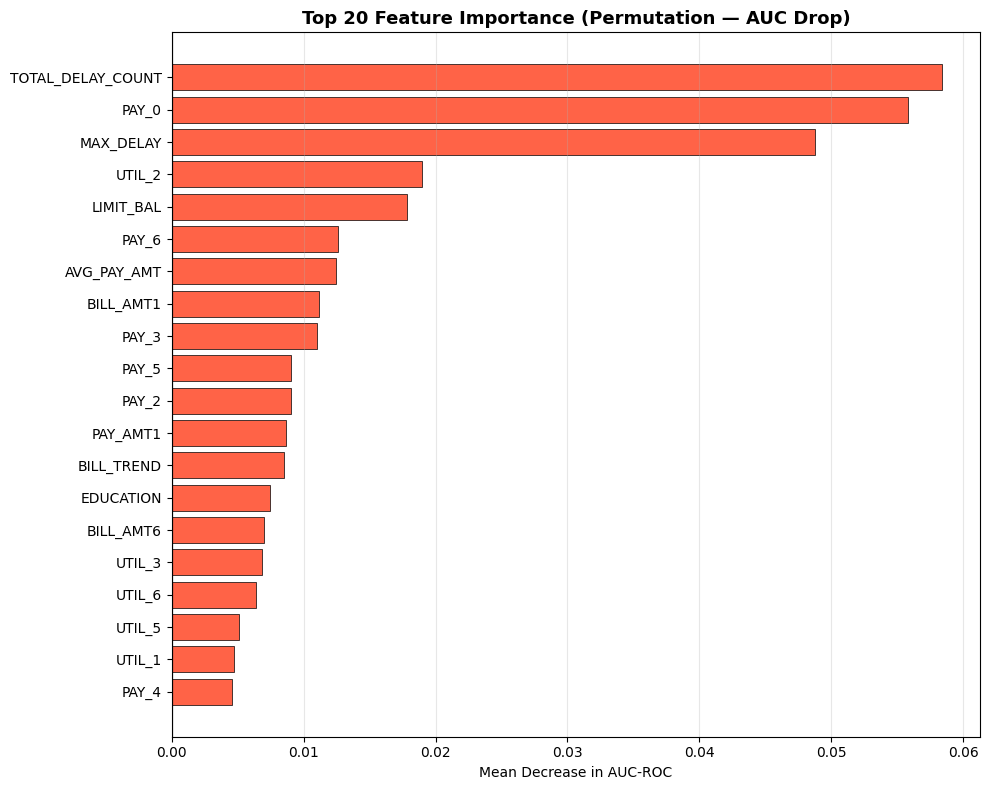


Top 10 Fitur Terpenting:
   1. TOTAL_DELAY_COUNT         : 0.05837
   2. PAY_0                     : 0.05584
   3. MAX_DELAY                 : 0.04879
   4. UTIL_2                    : 0.01895
   5. LIMIT_BAL                 : 0.01786
   6. PAY_6                     : 0.01261
   7. AVG_PAY_AMT               : 0.01242
   8. BILL_AMT1                 : 0.01115
   9. PAY_3                     : 0.01103
  10. PAY_5                     : 0.00904


In [22]:
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin

class TorchWrapper(ClassifierMixin, BaseEstimator):
    def __init__(self):
        self.classes_ = np.array([0, 1])  # wajib ada untuk sklearn classifier

    def fit(self, X, y):
        return self

    def predict_proba(self, X):
        model.eval()
        with torch.no_grad():
            out = model(torch.FloatTensor(X).to(device)).cpu().numpy()
        return np.column_stack([1 - out, out])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

print("Menghitung permutation importance... (mungkin butuh beberapa menit)")
wrapper = TorchWrapper()

result = permutation_importance(
    wrapper, X_test_sc, y_test.values,
    n_repeats=15, random_state=42, scoring='roc_auc', n_jobs=-1
)

feat_imp = pd.Series(result.importances_mean, index=X.columns).sort_values()
top20    = feat_imp.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors  = ['tomato' if v > 0 else 'steelblue' for v in top20.values]
ax.barh(top20.index, top20.values, color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Top 20 Feature Importance (Permutation — AUC Drop)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Decrease in AUC-ROC')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 10 Fitur Terpenting:")
for rank, (feat, imp) in enumerate(feat_imp.nlargest(10).items(), 1):
    print(f"  {rank:2d}. {feat:<25} : {imp:.5f}")

## 🚀 10. Fungsi Prediksi Nasabah Baru

In [24]:
def predict_default(raw_data: dict, threshold: float = best_thresh) -> dict:
    # \"\"\"
    # Prediksi default untuk satu nasabah baru.

    # Parameters
    # ----------
    # raw_data : dict
    #     Data nasabah dengan key sama seperti kolom dataset asli (tanpa DEFAULT).
    # threshold : float
    #     Batas probabilitas untuk menentukan kelas (default = threshold optimal).

    # Returns
    # -------
    # dict berisi probabilitas dan label prediksi.
    # \"\"\"
    row = pd.DataFrame([raw_data])

    # Feature engineering (sama seperti training)
    for i in range(1, 7):
        row[f'UTIL_{i}']      = row[f'BILL_AMT{i}'] / (row['LIMIT_BAL'] + 1)
        row[f'PAY_RATIO_{i}'] = row[f'PAY_AMT{i}']  / (row[f'BILL_AMT{i}'].abs() + 1)

    pay_st = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
    row['TOTAL_DELAY_COUNT'] = (row[pay_st] > 0).sum(axis=1)
    row['MAX_DELAY']         =  row[pay_st].max(axis=1)
    row['AVG_DELAY']         =  row[pay_st].mean(axis=1)

    bc = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
    pc = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']
    row['BILL_TREND']    = row['BILL_AMT1'] - row['BILL_AMT6']
    row['PAY_AMT_TREND'] = row['PAY_AMT1']  - row['PAY_AMT6']
    row['AVG_BILL']      = row[bc].mean(axis=1)
    row['AVG_PAY_AMT']   = row[pc].mean(axis=1)

    # Pastikan urutan kolom sama persis
    row = row[X.columns]
    row_sc = scaler.transform(row)

    model.eval()
    with torch.no_grad():
        prob = model(torch.FloatTensor(row_sc).to(device)).item()

    return {
        'probability_default': round(prob, 4),
        'prediction'         : 'DEFAULT ⚠️' if prob >= threshold else 'NO DEFAULT ✅',
        'threshold_used'     : threshold
    }

# ── Contoh Prediksi ───────────────────────────────────────────────────────────
sample_nasabah = {
    'LIMIT_BAL': 50000, 'SEX': 2, 'EDUCATION': 2, 'MARRIAGE': 1, 'AGE': 35,
    'PAY_0': 2,  'PAY_2': 2,  'PAY_3': 2,  'PAY_4': 0,  'PAY_5': 0,  'PAY_6': 0,
    'BILL_AMT1': 40000, 'BILL_AMT2': 38000, 'BILL_AMT3': 35000,
    'BILL_AMT4': 30000, 'BILL_AMT5': 25000, 'BILL_AMT6': 20000,
    'PAY_AMT1':  1000,  'PAY_AMT2':  1000,  'PAY_AMT3':  2000,
    'PAY_AMT4':  2000,  'PAY_AMT5':  3000,  'PAY_AMT6':  3000
}

result_nasabah = predict_default(sample_nasabah)
print("── Hasil Prediksi Nasabah ──────────────────────────")
print(f"  Probabilitas Default  : {result_nasabah['probability_default']:.2%}")
print(f"  Prediksi              : {result_nasabah['prediction']}")
print(f"  Threshold digunakan   : {result_nasabah['threshold_used']:.2f}")


── Hasil Prediksi Nasabah ──────────────────────────
  Probabilitas Default  : 92.41%
  Prediksi              : DEFAULT ⚠️
  Threshold digunakan   : 0.58


## 📋 11. Ringkasan Model

In [25]:
test_auc = roc_auc_score(test_true, test_probs)
best_idx = np.argmin(np.abs(thresholds_plot - best_thresh))

print("=" * 60)
print("        RINGKASAN MODEL — Credit Default Prediction")
print("=" * 60)
print(f"  Arsitektur      : DNN  (256→128→64→32→1)")
print(f"  Regularisasi    : BatchNorm + Dropout + Weight Decay")
print(f"  Imbalance Fix   : SMOTE (training set only)")
print(f"  Optimizer       : Adam + ReduceLROnPlateau")
print(f"  Loss Function   : Binary Cross-Entropy")
print(f"  Total Parameters: {sum(p.numel() for p in model.parameters()):,}")
print("-" * 60)
print(f"  Test AUC-ROC    : {test_auc:.4f}")
print(f"  Test F1-Score   : {f1s[best_idx]:.4f}")
print(f"  Test Precision  : {precisions[best_idx]:.4f}")
print(f"  Test Recall     : {recalls[best_idx]:.4f}")
print(f"  Best Threshold  : {best_thresh:.2f}")
print("=" * 60)
print("\n✅ Model siap digunakan untuk prediksi nasabah baru!")


        RINGKASAN MODEL — Credit Default Prediction
  Arsitektur      : DNN  (256→128→64→32→1)
  Regularisasi    : BatchNorm + Dropout + Weight Decay
  Imbalance Fix   : SMOTE (training set only)
  Optimizer       : Adam + ReduceLROnPlateau
  Loss Function   : Binary Cross-Entropy
  Total Parameters: 55,233
------------------------------------------------------------
  Test AUC-ROC    : 0.7523
  Test F1-Score   : 0.5107
  Test Precision  : 0.4953
  Test Recall     : 0.5271
  Best Threshold  : 0.58

✅ Model siap digunakan untuk prediksi nasabah baru!
